In [1]:
import numpy as np
import matplotlib.pyplot as plt
import casadi as ca

In [2]:
# Physical constants
G       = 9.81      # gravitational acceleration [m/s^2]
RHO     = 1.225     # air density [kg/m^3]

# Vehicle parameters
MASS    = 10.0      # mass [kg]
S       = 0.5       # wing reference area [m^2]
C_D0    = 0.02      # zero-lift drag coefficient
K_DRAG  = 0.05      # induced drag factor
T_MAX   = 30.0      # maximum thrust [N]
V_STALL = 15.0      # stall speed [m/s]
V_MAX   = 50.0      # maximum airspeed [m/s]
TAU     = 1.0       # flight path angle time constant [s]

# Initial conditions
X0      = 0.0       # initial horizontal position [m]
H0      = 0.0       # initial altitude [m]
V0      = 30.0      # initial airspeed [m/s]
GAMMA0  = 0.0       # initial flight path angle [rad]

# Mission
X_GOAL  = 7000.0   # goal horizontal position [m]
H_GOAL  = 0.0       # goal altitude [m]
EPS_GOAL = 200.0    # goal acceptance radius [m]
T_MAX_SIM = 1000.0  # max simulation time [s]
DT      = 0.5       # integration timestep [s]

In [3]:
# ── symbolic state and control ──────────────────────────────
x     = ca.SX.sym('x')        # horizontal position [m]
h     = ca.SX.sym('h')        # altitude [m]
v     = ca.SX.sym('v')        # airspeed [m/s]
gamma = ca.SX.sym('gamma')    # flight path angle [rad]

state = ca.vertcat(x, h, v, gamma)   # shape (4, 1)

# control inputs
T          = ca.SX.sym('T')           # thrust [N]
gamma_cmd  = ca.SX.sym('gamma_cmd')  # commanded flight path angle [rad]

controls = ca.vertcat(T, gamma_cmd)   # shape (2, 1)

# ── drag model ───────────────────────────────────────────────
C_L  = (2 * MASS * G * ca.cos(gamma)) / (RHO * v**2 * S)
C_D  = C_D0 + K_DRAG * C_L**2
drag = 0.5 * RHO * v**2 * S * C_D

# ── equations of motion ──────────────────────────────────────
xdot     = v * ca.cos(gamma)
hdot     = v * ca.sin(gamma)
vdot     = (T - drag) / MASS - G * ca.sin(gamma)
gammadot = (gamma_cmd - gamma) / TAU

ode = ca.vertcat(xdot, hdot, vdot, gammadot)   # shape (4, 1)

# ── build integrator ─────────────────────────────────────────
intg = ca.integrator(
    'intg',
    'cvodes',
    {
        'x':   state,
        'p':   controls,
        'ode': ode,
    },
    0.0,    # t0
    DT,     # tf
    {}      # options dict (empty for now)
)

print("Integrator built successfully")
print(f"State:    {state}")
print(f"Controls: {controls}")
print(f"ODE:      {ode}")

Integrator built successfully
State:    [x, h, v, gamma]
Controls: [T, gamma_cmd]
ODE:      @1=0.5, [(v*cos(gamma)), (v*sin(gamma)), (((T-((@1*(0.6125*sq(v)))*(0.02+(0.05*sq(((196.2*cos(gamma))/(@1*(1.225*sq(v)))))))))/10)-(9.81*sin(gamma))), (gamma_cmd-gamma)]


In [4]:
# test one integration step at nominal conditions
s0 = [X0, H0, V0, GAMMA0]   # initial state
u0 = [T_MAX, np.radians(15)] # full thrust, 15 deg climb command

result = intg(x0=s0, p=u0)

s1 = result['xf'].full().flatten()   # next state as numpy array

print(f"Initial state : x={s0[0]:.1f}m  h={s0[1]:.1f}m  v={s0[2]:.2f}m/s  gamma={np.degrees(s0[3]):.2f}deg")
print(f"Next state    : x={s1[0]:.1f}m  h={s1[1]:.1f}m  v={s1[2]:.2f}m/s  gamma={np.degrees(s1[3]):.2f}deg")
print(f"Delta         : dx={s1[0]-s0[0]:.2f}m  dh={s1[1]-s0[1]:.2f}m  dv={s1[2]-s0[2]:.4f}m/s  dgamma={np.degrees(s1[3]-s0[3]):.4f}deg")

Initial state : x=0.0m  h=0.0m  v=30.00m/s  gamma=0.00deg
Next state    : x=15.2m  h=0.9m  v=30.86m/s  gamma=5.90deg
Delta         : dx=15.21m  dh=0.85m  dv=0.8580m/s  dgamma=5.9020deg


In [5]:
def simulate_hybrid(theta_cmd_deg, t_sw, gamma_cmd_deg,
                    dt=DT, t_max=T_MAX_SIM):
    """
    Simulate hybrid fixed-wing trajectory.

    Powered phase: constant thrust T_MAX, constant climb command theta_cmd
    Glide phase:   zero thrust, constant glide command gamma_cmd
    Switch:        triggered at t = t_sw (fixed time)

    Parameters
    ----------
    theta_cmd_deg : float   powered phase climb angle command [deg]
    t_sw          : float   switch time [s]
    gamma_cmd_deg : float   glide phase angle command [deg], positive = descending
    dt            : float   timestep [s]
    t_max         : float   max simulation time [s]

    Returns
    -------
    traj : list of dicts
           keys: 't', 'x', 'h', 'v', 'gamma', 'mode'
    info : dict
           keys: 't_switch', 'x_switch', 'h_switch',
                 'v_switch', 'gamma_switch', 'reached_goal'
    """

    # convert to radians
    theta_cmd  = np.radians(theta_cmd_deg)
    gamma_cmd  = np.radians(gamma_cmd_deg)

    # initial state
    state = np.array([X0, H0, V0, GAMMA0])

    # mode and info
    mode = 'powered'
    info = {
        't_switch'     : None,
        'x_switch'     : None,
        'h_switch'     : None,
        'v_switch'     : None,
        'gamma_switch' : None,
        'reached_goal' : False,
    }

    traj = []
    t    = 0.0

    while t < t_max:
        x, h, v, gamma = state

        # record current step
        traj.append({
            't':     t,
            'x':     x,
            'h':     h,
            'v':     v,
            'gamma': np.degrees(gamma),
            'mode':  mode,
        })

        # check goal
        dist = np.sqrt((x - X_GOAL)**2 + (h - H_GOAL)**2)
        if dist <= EPS_GOAL:
            info['reached_goal'] = True
            break

        # check ground crash (not at goal)
        if h < 0.0 and t > 0.0:
            break

        # check mode switch
        if mode == 'powered' and t >= t_sw:
            mode = 'glide'
            info['t_switch']     = t
            info['x_switch']     = x
            info['h_switch']     = h
            info['v_switch']     = v
            info['gamma_switch'] = np.degrees(gamma)
            print(f"SWITCH at t={t:.1f}s  "
                  f"x={x:.0f}m  h={h:.0f}m  "
                  f"v={v:.2f}m/s  gamma={np.degrees(gamma):.2f}deg")

        # set controls based on mode
        if mode == 'powered':
            u = [T_MAX, theta_cmd]
        else:
            u = [0.0, -gamma_cmd]     # negative: gamma_cmd>0 means descend

        # integrate one step
        result = intg(x0=state, p=u)
        state  = result['xf'].full().flatten()

        # clamp speed to physical bounds
        state[2] = np.clip(state[2], V_STALL, V_MAX)

        t += dt

    return traj, info

SWITCH at t=60.0s  x=1513m  h=397m  v=21.36m/s  gamma=15.00deg

Reached goal : False
Switch time  : 60.0
Switch x     : 1513 m
Switch h     : 397 m
Switch v     : 21.36 m/s
Switch gamma : 15.00 deg
Traj length  : 433 steps


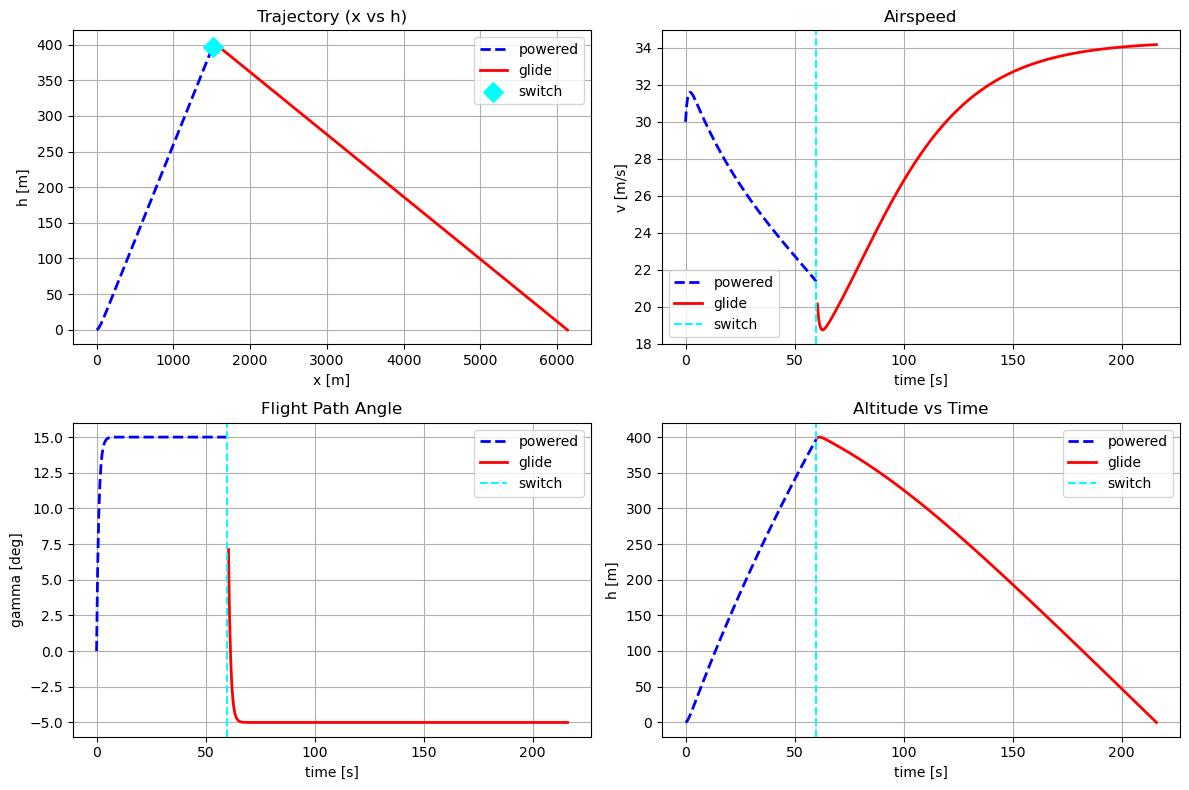

In [6]:
# test: climb for 60s then glide
traj, info = simulate_hybrid(
    theta_cmd_deg = 15.0,    # climb at 15 deg
    t_sw          = 60.0,    # switch at t=60s
    gamma_cmd_deg = 5.0,     # glide at 5 deg descent
)

print(f"\nReached goal : {info['reached_goal']}")
print(f"Switch time  : {info['t_switch']}")
print(f"Switch x     : {info['x_switch']:.0f} m")
print(f"Switch h     : {info['h_switch']:.0f} m")
print(f"Switch v     : {info['v_switch']:.2f} m/s")
print(f"Switch gamma : {info['gamma_switch']:.2f} deg")
print(f"Traj length  : {len(traj)} steps")

# extract arrays
times  = [s['t']     for s in traj]
xs     = [s['x']     for s in traj]
hs     = [s['h']     for s in traj]
vs     = [s['v']     for s in traj]
gammas = [s['gamma'] for s in traj]
modes  = [s['mode']  for s in traj]

pow_idx = [i for i, m in enumerate(modes) if m == 'powered']
gli_idx = [i for i, m in enumerate(modes) if m == 'glide']

# plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# trajectory
axes[0,0].plot([xs[i] for i in pow_idx],
               [hs[i] for i in pow_idx],
               'b--', linewidth=2, label='powered')
axes[0,0].plot([xs[i] for i in gli_idx],
               [hs[i] for i in gli_idx],
               'r-',  linewidth=2, label='glide')
if info['x_switch'] is not None:
    axes[0,0].scatter([info['x_switch']], [info['h_switch']],
                      marker='D', color='cyan', s=100,
                      zorder=5, label='switch')
axes[0,0].set_xlabel('x [m]')
axes[0,0].set_ylabel('h [m]')
axes[0,0].set_title('Trajectory (x vs h)')
axes[0,0].legend()
axes[0,0].grid(True)

# airspeed
axes[0,1].plot([times[i] for i in pow_idx],
               [vs[i]    for i in pow_idx],
               'b--', linewidth=2, label='powered')
axes[0,1].plot([times[i] for i in gli_idx],
               [vs[i]    for i in gli_idx],
               'r-',  linewidth=2, label='glide')
if info['t_switch'] is not None:
    axes[0,1].axvline(info['t_switch'], color='cyan',
                      linestyle='--', label='switch')
axes[0,1].set_xlabel('time [s]')
axes[0,1].set_ylabel('v [m/s]')
axes[0,1].set_title('Airspeed')
axes[0,1].legend()
axes[0,1].grid(True)

# flight path angle
axes[1,0].plot([times[i] for i in pow_idx],
               [gammas[i] for i in pow_idx],
               'b--', linewidth=2, label='powered')
axes[1,0].plot([times[i] for i in gli_idx],
               [gammas[i] for i in gli_idx],
               'r-',  linewidth=2, label='glide')
if info['t_switch'] is not None:
    axes[1,0].axvline(info['t_switch'], color='cyan',
                      linestyle='--', label='switch')
axes[1,0].set_xlabel('time [s]')
axes[1,0].set_ylabel('gamma [deg]')
axes[1,0].set_title('Flight Path Angle')
axes[1,0].legend()
axes[1,0].grid(True)

# altitude vs time
axes[1,1].plot([times[i] for i in pow_idx],
               [hs[i]    for i in pow_idx],
               'b--', linewidth=2, label='powered')
axes[1,1].plot([times[i] for i in gli_idx],
               [hs[i]    for i in gli_idx],
               'r-',  linewidth=2, label='glide')
if info['t_switch'] is not None:
    axes[1,1].axvline(info['t_switch'], color='cyan',
                      linestyle='--', label='switch')
axes[1,1].set_xlabel('time [s]')
axes[1,1].set_ylabel('h [m]')
axes[1,1].set_title('Altitude vs Time')
axes[1,1].legend()
axes[1,1].grid(True)

plt.tight_layout()
plt.show()